#Importação dos dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
dados = pd.read_csv("drive/My Drive/3° Período/IA/Atividade avaliativa da 2ª Unidade/fetal_health.csv")

# Pandas profiling

In [ ]:
!pip install pandas_profiling

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 41.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 56.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 33.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.4/455.4 kB 49.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 65.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=8f938f68ac3be47b112edfa1355c928900d65a84316fb86ba7b84efbb0ea547c
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attemp

In [ ]:
from pandas_profiling import ProfileReport


profile = ProfileReport(dados)
profile

Output hidden; open in https://colab.research.google.com to view.

# Análise exploratória


1. Qual é o número de linhas e variáveis?
**Linhas: 2126 e Variáveis: 22**

2. Quantas classes a variável de saída possui? Quais são elas?
**3 classes. As classes são: Normal, Suspeito e Patológico - Que foram representadas como 1, 2 e 3, respectivamente.**

3. Variáveis com dados faltantes
**Não existem variáveis com dados faltantes.**

4. Linhas duplicadas
**Existem 11 linhas duplicadas.**

5. Existe alguma variável mais importante para avaliação da saúde fetal?
**As variáveis histogram_mean e percentage_of_time_with_abnormal_long_term_variability possuem uma correlação próxima de 0.5, sendo consideradas como variáveis importantes na avaliação.**

6. Variáveis com alta correlação
**Não existem variáveis com alta correlação com a variável de saída, apenas em um nível próximo de 0,5. Mas existem variáveis que possuem alta correlação entre si, a exemplo de histogram_min e histogram_width, histogram_median e baseline value.**

7. Variáveis com correlação negativa
**Não existem variáveis com correlação negativa com a variável de saída, apenas em um nível próximo 0,5. Mas existem variáveis que possuem correlação negativa entre si, a exemplo de histogram_mode e histogram_median, histogram_variance e histogram_min.**

8. Distribuições dos gráficos/histogramas está normal em todos os casos?
**Não. Em alguns casos não há uma distibuição adequada das frequências.**

9. Quantas variáveis númericas e categóricas?
**19 variáveis numéricas e 3 variáveis categóricas**

10. O número de linhas permite uma boa aprendizagem levando em consideração o número de variáveis?

**Sim. Ainda que existam 22 variáveis, há um número significativo de linhas que são suficientes para o processo de aprendizagem.**

11. A respeito da variável de saída, a classe majoritária possui um número muito maior que as demais? Isso reflete a realidade?
**Sim. Apesar da classe majoritária ter um número muito maior que o número das outras, isso reflete a realidade pois a maioria dos fetos são saudáveis. Entretanto, a partir da exploração da adequação de modelos, pode ser necessário realizar operações para equilibrar tal diferença.**

# Separando conjunto de dados

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = dados[dados.columns[:-1]]
Y = dados[dados.columns[-1:]]

x_train, x_test, y_train, y_test = train_test_split(
 X, Y, test_size=0.20, random_state=42)

In [ ]:
print("Amostra de padrões de entrada:")
print(x_train)

print("Amostra de saídas:")
print(y_train)

Amostra de padrões de entrada:
      baseline value  accelerations  fetal_movement  uterine_contractions  \
1233           125.0          0.000           0.000                 0.008   
480            140.0          0.000           0.000                 0.001   
1111           122.0          0.000           0.000                 0.000   
1303           137.0          0.005           0.000                 0.005   
861            142.0          0.003           0.000                 0.004   
...              ...            ...             ...                   ...   
1638           130.0          0.009           0.001                 0.004   
1095           123.0          0.012           0.000                 0.002   
1130           122.0          0.005           0.000                 0.004   
1294           115.0          0.003           0.000                 0.008   
860            142.0          0.001           0.000                 0.004   

      light_decelerations  severe_decelerati

In [ ]:
print("Tamanho total da base de dados = ",len(X))
print("Tamanho do conjunto de treinamento = ",len(x_train))
print("Tamanho do conjunto de testes = ",len(x_test))

Tamanho total da base de dados =  2126
Tamanho do conjunto de treinamento =  1700
Tamanho do conjunto de testes =  426


# Modelos

In [ ]:
from sklearn.metrics import *

### Árvore de Decisão

In [ ]:
from sklearn import tree

clfTree = tree.DecisionTreeClassifier()
clfTree = clfTree.fit(x_train, y_train)

y_predicted = clfTree.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = clfTree.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("Métricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

Métricas de Treinamento
Acurácia =  1.0

Matriz de Confusão
[[1322    0    0]
 [   0  231    0]
 [   0    0  147]]
-------------------------------
Métricas de Testes
Acurácia =  0.9225352112676056

Matriz de Confusão
[[312  17   4]
 [ 10  54   0]
 [  2   0  27]]


### Perceptron

In [ ]:
from sklearn.linear_model import Perceptron

perceptron = Perceptron(random_state = 0)
perceptron.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Perceptron()

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

y_predicted = perceptron.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = perceptron.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("\nMétricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

Métricas de Treinamento
Acurácia =  0.82

Matriz de Confusão
[[1221  101    0]
 [  95  136    0]
 [  55   55   37]]
-------------------------------

Métricas de Testes
Acurácia =  0.8333333333333334

Matriz de Confusão
[[309  24   0]
 [ 22  42   0]
 [ 11  14   4]]


### KNN

In [ ]:
#Com n = 2
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=2)
neigh.fit(x_train, y_train)

y_predicted = neigh.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = neigh.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("\nMétricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Métricas de Treinamento
Acurácia =  0.9447058823529412

Matriz de Confusão
[[1322    0    0]
 [  69  162    0]
 [   9   16  122]]
-------------------------------

Métricas de Testes
Acurácia =  0.8826291079812206

Matriz de Confusão
[[322  10   1]
 [ 29  35   0]
 [  5   5  19]]


In [ ]:
#Com n = 4
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=4)
neigh.fit(x_train, y_train)

y_predicted = neigh.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = neigh.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("\nMétricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

Métricas de Treinamento
Acurácia =  0.9270588235294117

Matriz de Confusão
[[1303   12    7]
 [  79  149    3]
 [  12   11  124]]
-------------------------------

Métricas de Testes
Acurácia =  0.8802816901408451

Matriz de Confusão
[[321  11   1]
 [ 29  35   0]
 [  4   6  19]]


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


### Redes Neurais

In [ ]:
#Com configurações do padrão
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier()
clf = clf.fit(x_train, y_train)

y_predicted = clf.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = clf.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("Métricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Métricas de Treinamento
Acurácia =  0.8876470588235295

Matriz de Confusão
[[1221   91   10]
 [  61  167    3]
 [   7   19  121]]
-------------------------------
Métricas de Testes
Acurácia =  0.8591549295774648

Matriz de Confusão
[[299  27   7]
 [ 16  46   2]
 [  2   6  21]]


In [ ]:
#Com configurações personalizadas
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                 hidden_layer_sizes=(26, 26), random_state=1)
clf = clf.fit(x_train, y_train)

y_predicted = clf.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = clf.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("Métricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Métricas de Treinamento
Acurácia =  0.9070588235294118

Matriz de Confusão
[[1266   46   10]
 [  72  157    2]
 [  12   16  119]]
-------------------------------
Métricas de Testes
Acurácia =  0.8849765258215962

Matriz de Confusão
[[310  21   2]
 [ 19  44   1]
 [  3   3  23]]


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


### Regressão logística

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(x_train, y_train)
clf = clf.fit(x_train, y_train)

y_predicted = clf.predict(x_train)
accuracy = accuracy_score(y_train,y_predicted)
conf_matrix = confusion_matrix(y_train,y_predicted)

print("Métricas de Treinamento")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

print("-------------------------------")

y_predicted = clf.predict(x_test)
accuracy = accuracy_score(y_test,y_predicted)
conf_matrix = confusion_matrix(y_test,y_predicted)

print("Métricas de Testes")
print("Acurácia = ",accuracy)
print("\nMatriz de Confusão")
print(conf_matrix)

Métricas de Treinamento
Acurácia =  0.8611764705882353

Matriz de Confusão
[[1271   33   18]
 [ 137   86    8]
 [  16   24  107]]
-------------------------------
Métricas de Testes
Acurácia =  0.8685446009389671

Matriz de Confusão
[[318   9   6]
 [ 32  30   2]
 [  3   4  22]]


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

# Conclusões

**A Árvore de Decisão foi o modelo que obteve o melhor desempenho no processo de classificação tanto nas métricas do conjunto de treinamento quanto nas métricas do conjunto de testes. Ademais, por ser um modelo interpretativo, o conjunto permite uma análise mais detalhada do processo de classificação com a devida interpretação dos resultados obtidos, entretanto ao realizar o plot da árvore é possível observar que o modelo não é explicativo.**


Métricas obtidas pela Árvore de Decisão:

**Acurácia no conjunto de treinamento: 1.0**

**Acurácia no conjunto de testes: 0.9295774647887324**

A respeito da matriz de confusão no conjunto de testes, os números não refletem uma má classificação. Entretanto, devido a importância da classificação adequada da saúde fetal, seria possível adotar técnicas como undersampling e oversampling, como foi feito no outro Google Colab anexado. Nenhuma das duas técnicas foi capaz de melhorar significativamente o processo de classificação da classe majoritária.

Mesmo após a utilização das técnicas, a Árvore Decisão mostra-se como o modelo mais adequado para o problema.

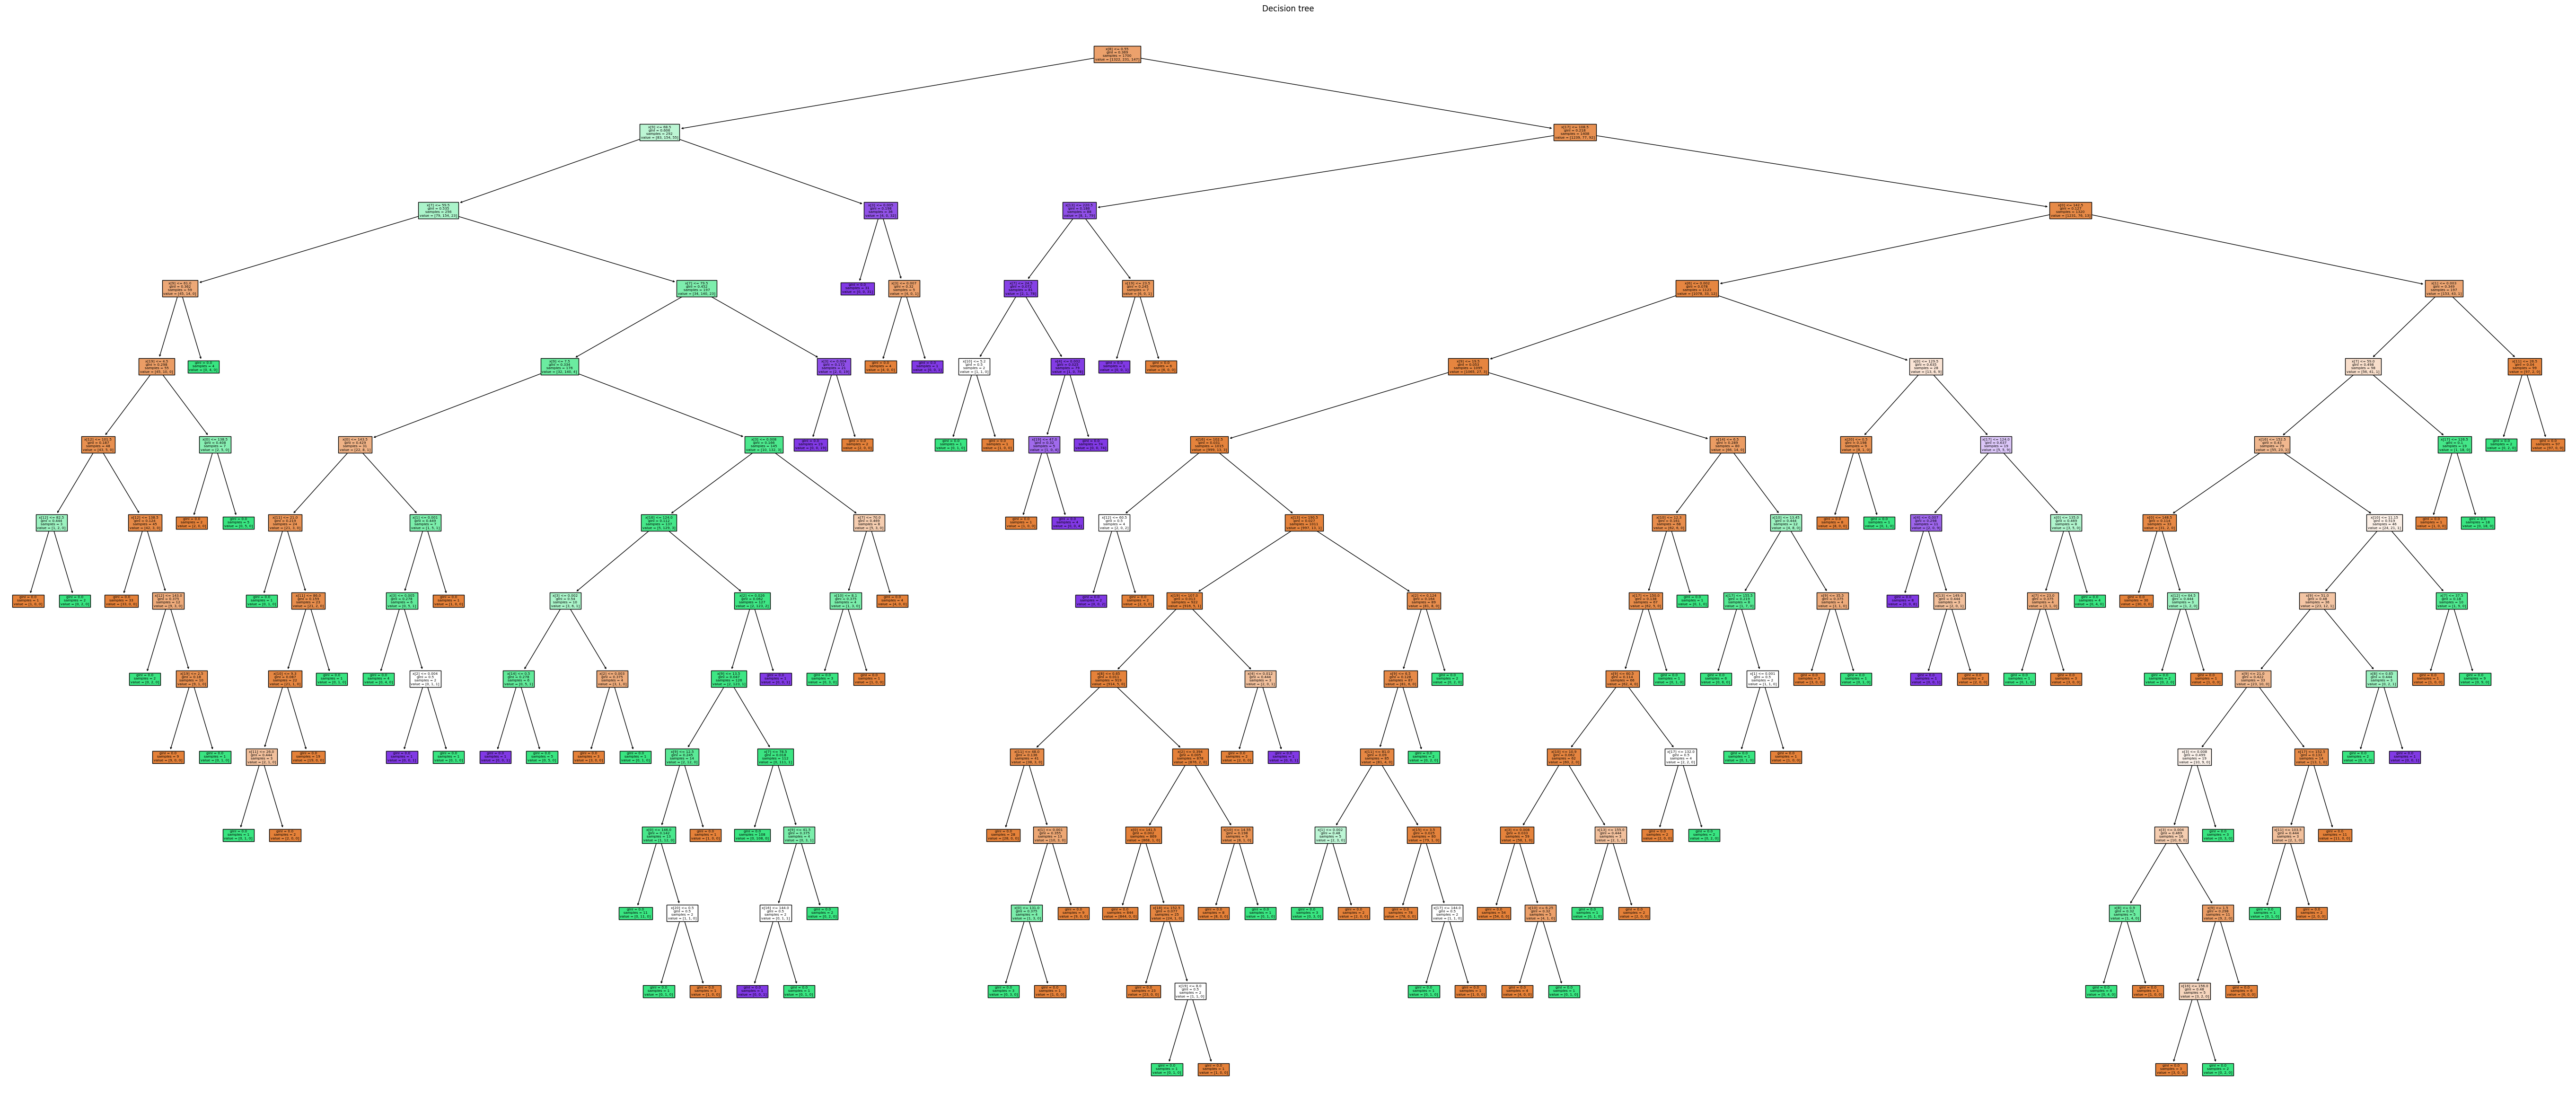

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(70,30))
tree.plot_tree(clfTree, filled=True)
plt.title("Decision tree")
plt.show()